<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-03-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 03
### Data Preprocessing, Feature Engineering, Missing Data Handling, and Exploratory Data Analysis (EDA)

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | 125M1H020 |
| **Student Name** | Amit Chame |
| **Assignment Date** | 07-08-2026 |
| **Submission Date** | 26-08-2026 |
</div>

---
## Instructions to Students

- Fill in your **PRN**, **Name**, **Class/Division**, and **Submission Date** in the header table above.
- Write all Python code in the code cells provided below each question.
- Execute each code cell and ensure there are **no errors** before submission.
- Do **not** modify the question cells.
- Rename this file as `<YourPRN>_ADS_Lab_A3.ipynb` before submitting.
- Submit the completed `.ipynb` file on the Google Classroom portal by the due date.

---

## Section 1: Data Preprocessing and Exploration
**Course Outcome: CO2**

> Perform data cleaning, outlier detection & removal, feature scaling, and categorical encoding on practical datasets.

### Question 1(a) - Outlier Removal and Min-Max Scaling on Electronic Product Prices

You are provided with a dataset containing prices of various electronic products. Some of the entries are outliers due to data entry errors. Your task is to remove these outliers and normalize the remaining prices using Min-Max scaling. (`product_prices.csv`)


In [49]:
# Question 1(a) — Outlier Detection, Removal, and Min-Max Scaling
# Write your code below

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
df_prices = pd.read_csv('product_prices.csv')
print("Initial Dataset")
print(df_prices.head(10))
print( df_prices.shape)
Q1 = df_prices['Price'].quantile(0.25)
Q3 = df_prices['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(Q1)
print(Q3)
print(IQR)
print(lower_limit)
print(upper_limit)
outliers = df_prices[(df_prices['Price'] < lower_limit) | (df_prices['Price'] > upper_limit)]
print(len(outliers))
print(outliers[['Product_Name', 'Category', 'Price']])
df_prices_cleaned = df_prices[(df_prices['Price'] >= lower_limit) & (df_prices['Price'] <= upper_limit)].copy()
print(df_prices_cleaned.shape)
min_price = df_prices_cleaned['Price'].min()
max_price = df_prices_cleaned['Price'].max()
df_prices_cleaned['Price_Normalized_Manual'] = (df_prices_cleaned['Price'] - min_price) / (max_price - min_price)
scaler = MinMaxScaler()
df_prices_cleaned['Price_Normalized_Sklearn'] = scaler.fit_transform(df_prices_cleaned[['Price']])
print(df_prices_cleaned[['Product_Name', 'Category', 'Price', 'Price_Normalized_Manual', 'Price_Normalized_Sklearn']].head(10))

# Expected Output: Cleaned DataFrame with outliers removed and prices normalized in range [0, 1]

Initial Dataset
   Product_ID                     Product_Name    Category   Price
0           0       Smartphone (Redmi Note 13)  Smartphone   15999
1           1  Smartphone (Samsung Galaxy M34)  Smartphone   18499
2           2     Smartphone (Realme Narzo 60)  Smartphone   14999
3           3   Smartphone (OnePlus Nord CE 3)  Smartphone   24999
4           4           Smartphone (iPhone 15)  Smartphone   72999
5           5            Smartphone (Vivo V29)  Smartphone  850000
6           6        Laptop (Lenovo IdeaPad 3)      Laptop   42990
7           7          Laptop (HP Pavilion 15)      Laptop   58990
8           8      Laptop (Dell Inspiron 3520)      Laptop   48490
9           9        Laptop (Asus Vivobook 16)      Laptop   52990
(35, 4)
1999.0
44490.0
42491.0
-61737.5
108226.5
2
                     Product_Name    Category   Price
5           Smartphone (Vivo V29)  Smartphone  850000
18  Headphones (boAt Rockerz 450)  Headphones  999000
(33, 4)
                       Pro

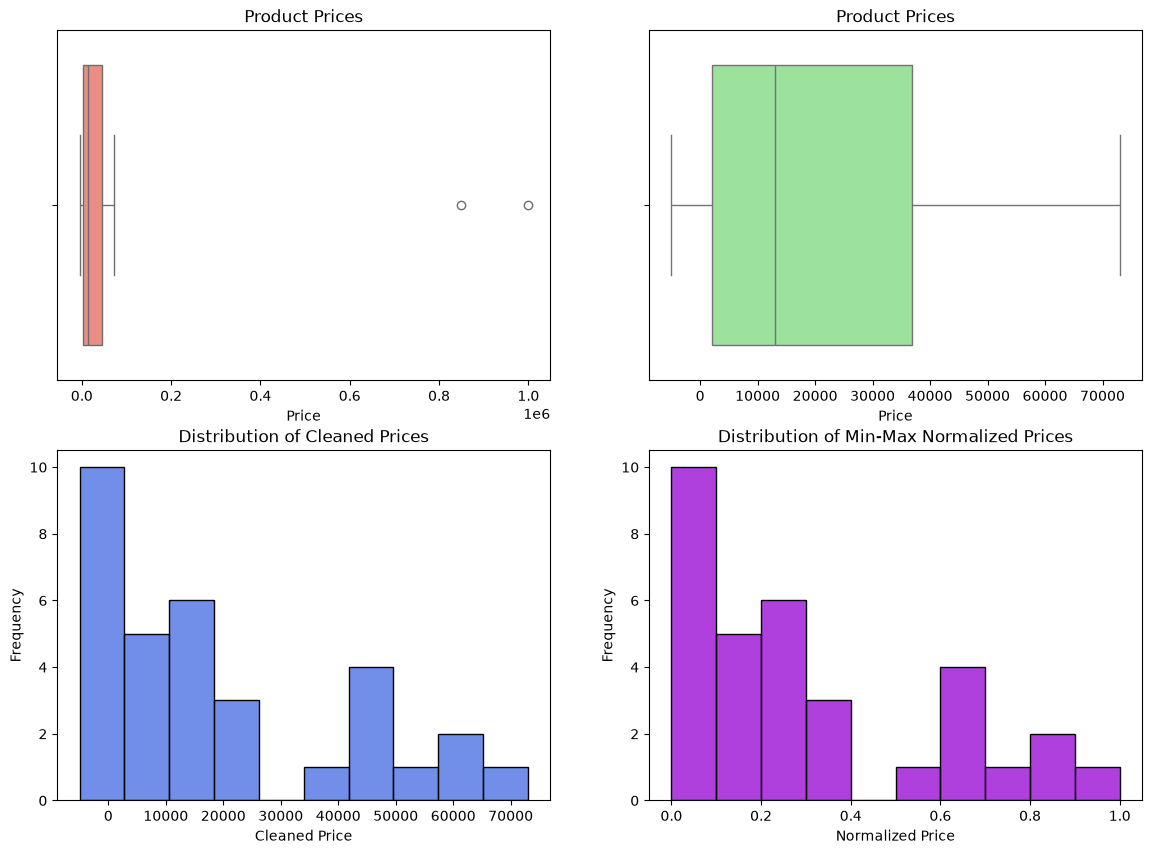

In [50]:
# Question 1(a) — Visualizations: Boxplots and Histograms Before and After
# Write your code below

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
sns.boxplot(x=df_prices['Price'], color='salmon')
plt.title('Product Prices')
plt.xlabel('Price')
plt.subplot(2, 2, 2)
sns.boxplot(x=df_prices_cleaned['Price'], color='lightgreen')
plt.title('Product Prices')
plt.xlabel('Price')
plt.subplot(2, 2, 3)
sns.histplot(df_prices_cleaned['Price'], bins=10, color='royalblue')
plt.title('Distribution of Cleaned Prices')
plt.xlabel('Cleaned Price')
plt.ylabel('Frequency')
plt.subplot(2, 2, 4)
sns.histplot(df_prices_cleaned['Price_Normalized_Manual'],bins=10, color='darkviolet')
plt.title('Distribution of Min-Max Normalized Prices')
plt.xlabel('Normalized Price')
plt.ylabel('Frequency')

plt.show()

### Question 1(b) - Gender Encoding and Statistical Summaries of Customer Ages

A retail store wants to analyze the age and gender distribution of its customers. You are required to encode the gender column and generate statistical summaries of customer ages. (`customers.csv`)


In [51]:
# Question 1(b) — Gender Encoding and Age Statistical Summaries
# Write your code below
df_customers = pd.read_csv('customers.csv')
print(df_customers.head(10))
df_customers['Gender_Encoded'] = df_customers['Gender'].map({'Male': 0, 'Female': 1})
df_encoded = pd.get_dummies(df_customers, columns=['Gender'], prefix='Gender', dtype=int)
print(df_encoded[['Customer_ID', 'Customer_Name', 'Age', 'Gender_Encoded', 'Gender_Female', 'Gender_Male', 'City']].head(10))
age_series = df_customers['Age']
age_mean = age_series.mean()
age_median = age_series.median()
age_mode = age_series.mode()[0]
age_std = age_series.std()
age_var = age_series.var()
age_min = age_series.min()
age_max = age_series.max()
age_range = age_max - age_min
age_q1 = age_series.quantile(0.25)
age_q3 = age_series.quantile(0.75)
age_iqr = age_q3 - age_q1
print(len(age_series))
print(age_mean)
print(age_median)
print(age_mode)
print(age_std)
print(age_var)
print(age_min)
print(age_max)
print(age_range)
print(age_q1)
print(age_q3)
print(age_iqr)
gender_age_summary = df_customers.groupby('Gender')['Age'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std_Dev='std',
    Min='min',
    Max='max'
)
print(gender_age_summary)

# Expected Output: Encoded DataFrame and comprehensive statistical breakdown of customer ages

  Customer_ID   Customer_Name  Age  Gender      City
0     CUST101      Amit Chame   23    Male      Pune
1     CUST102    Priya Sharma   29  Female    Mumbai
2     CUST103     Rahul Patil   34    Male    Nagpur
3     CUST104  Sneha Deshmukh   21  Female    Nashik
4     CUST105    Aniket Joshi   45    Male      Pune
5     CUST106  Pooja Kulkarni   31  Female    Mumbai
6     CUST107    Rohan Shinde   27    Male  Kolhapur
7     CUST108      Tanvi More   24  Female      Pune
8     CUST109    Aditya Kadam   38    Male   Solapur
9     CUST110      Neha Pawar   52  Female    Mumbai
  Customer_ID   Customer_Name  Age  Gender_Encoded  Gender_Female  \
0     CUST101      Amit Chame   23               0              0   
1     CUST102    Priya Sharma   29               1              1   
2     CUST103     Rahul Patil   34               0              0   
3     CUST104  Sneha Deshmukh   21               1              1   
4     CUST105    Aniket Joshi   45               0              0   
5  

C:\Users\amitc\AppData\Local\Temp\ipykernel_14024\676914453.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df_customers, palette='Set2')
C:\Users\amitc\AppData\Local\Temp\ipykernel_14024\676914453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Age', data=df_customers, palette='Pastel1')


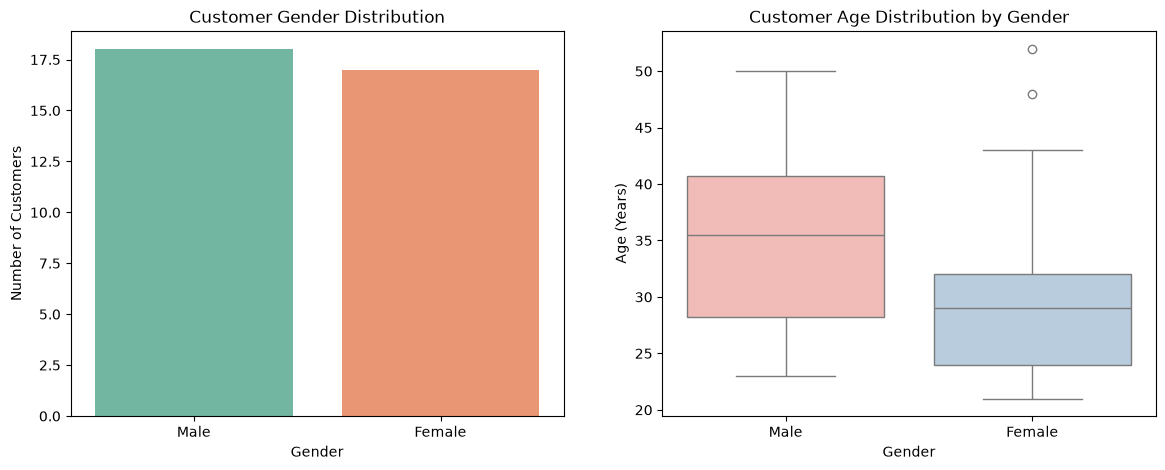

In [52]:
# Question 1(b) — Visualizations: Gender Distribution and Age Comparison
# Write your code below

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df_customers, palette='Set2')
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Age', data=df_customers, palette='Pastel1')
plt.title('Customer Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age (Years)')
plt.show()

## Section 2: Feature Engineering
**Course Outcome: CO2**

> Engineer new domain-specific features through discretization (binning), temporal extraction, conditional flags, and categorical mapping.

### Question 2(a) - Age Binning and Categorization for Targeted Marketing

You are working with a customer dataset and want to create new age categories, such as "Youth", "Adult", etc., to be used in targeted marketing. Your task is to define bins and convert the continuous age column into categorical age groups. (`ages.csv`)



  Customer_ID   Customer_Name  Age
0     CUST101      Amit Chame   19
1     CUST102    Priya Sharma   42
2     CUST103     Rahul Patil   28
3     CUST104  Sneha Deshmukh   65
4     CUST105    Aniket Joshi   33
5     CUST106  Pooja Kulkarni   22
6     CUST107    Rohan Shinde   54
7     CUST108      Tanvi More   31
8     CUST109    Aditya Kadam   47
9     CUST110      Neha Pawar   18
   Customer_ID    Customer_Name  Age    Age_Group
0      CUST101       Amit Chame   19        Youth
1      CUST102     Priya Sharma   42  Young Adult
2      CUST103      Rahul Patil   28  Young Adult
3      CUST104   Sneha Deshmukh   65       Senior
4      CUST105     Aniket Joshi   33  Young Adult
5      CUST106   Pooja Kulkarni   22        Youth
6      CUST107     Rohan Shinde   54  Middle-Aged
7      CUST108       Tanvi More   31  Young Adult
8      CUST109     Aditya Kadam   47  Middle-Aged
9      CUST110       Neha Pawar   18        Youth
10     CUST111  Saurabh Gaikwad   25        Youth
11     CUST112 

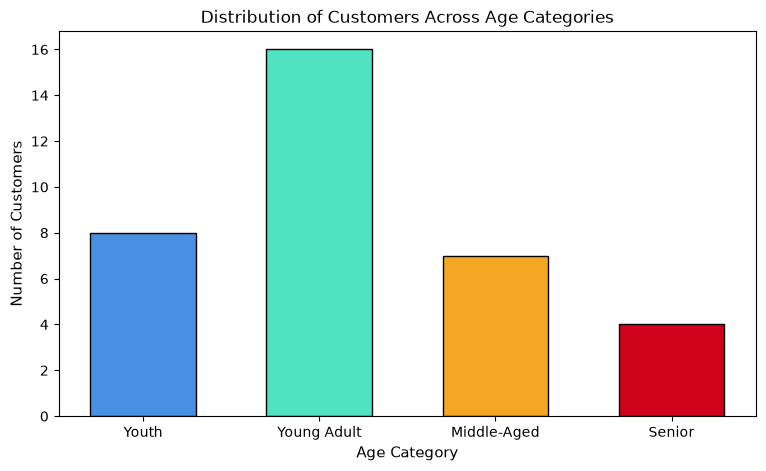

In [53]:
# Question 2(a) — Age Binning and Categorization
# Write your code below
df_ages = pd.read_csv('ages.csv')
print(df_ages.head(10))
age_bins = [0, 25, 45, 60, 100]
age_labels = ['Youth', 'Young Adult', 'Middle-Aged', 'Senior']
df_ages['Age_Group'] = pd.cut(df_ages['Age'], bins=age_bins, labels=age_labels, right=True)

print(df_ages.head(12))
age_group_counts = df_ages['Age_Group'].value_counts().sort_index()
age_group_pct = df_ages['Age_Group'].value_counts(normalize=True).sort_index() * 100

summary_table = pd.DataFrame({
    'Count': age_group_counts,
    'Percentage (%)': age_group_pct.round(2)
})
print(summary_table)
plt.figure(figsize=(9, 5))
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']
bars = plt.bar(age_group_counts.index, age_group_counts.values, color=colors, edgecolor='black', width=0.6)
plt.title('Distribution of Customers Across Age Categories')
plt.xlabel('Age Category', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.show()

# Expected Output: DataFrame with Age_Group column and bar chart showing age category distribution

### Question 2(b) - Date Feature Extraction, High-Value Transaction Flag, and Item Category Mapping

The retail store wants to understand customer purchasing behavior over time. Your task is to engineer the following features: (`sales.csv`)



  Transaction_ID   Customer_Name        Date   Item_Name  Quantity  \
0       TXN_1001      Amit Chame  2026-01-05      Laptop         1   
1       TXN_1002    Priya Sharma  2026-01-09       Mouse         3   
2       TXN_1003     Rahul Patil  2026-01-13    Keyboard         2   
3       TXN_1004  Sneha Deshmukh  2026-01-17      Tablet         1   
4       TXN_1005    Aniket Joshi  2026-01-21  Headphones         2   

   Unit_Price  TotalPurchase  
0       45000          45000  
1         600           1800  
2        1500           3000  
3       18000          18000  
4        2500           5000  
  Transaction_ID   Customer_Name       Date Day_of_Week     Month   Item_Name  \
0       TXN_1001      Amit Chame 2026-01-05      Monday   January      Laptop   
1       TXN_1002    Priya Sharma 2026-01-09      Friday   January       Mouse   
2       TXN_1003     Rahul Patil 2026-01-13     Tuesday   January    Keyboard   
3       TXN_1004  Sneha Deshmukh 2026-01-17    Saturday   January    

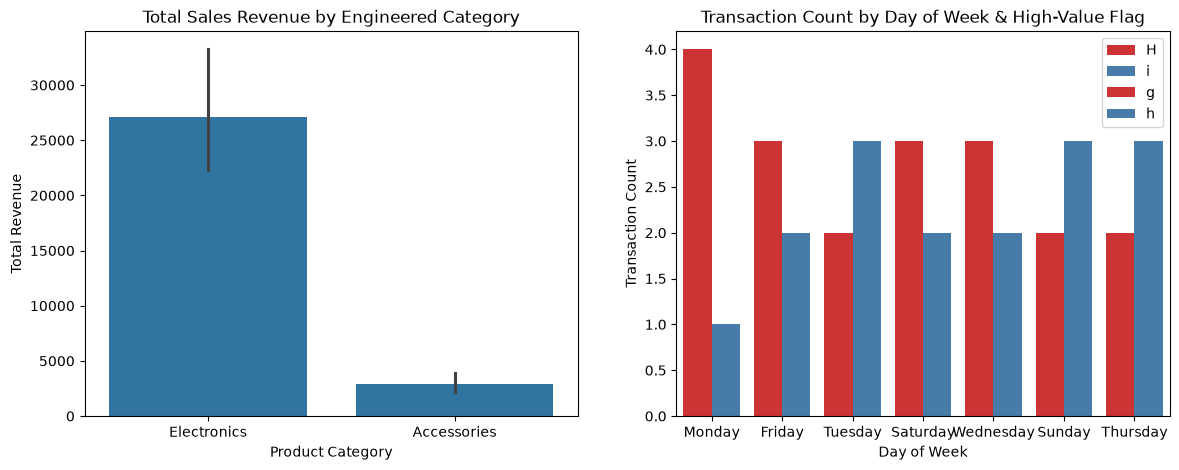

In [54]:
# Question 2(b) — Date Feature Extraction, High-Value Flag, and Item Category Mapping
# Write your code below

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_sales = pd.read_csv('sales.csv')
print(df_sales.head())
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Day_of_Week'] = df_sales['Date'].dt.day_name()
df_sales['Month'] = df_sales['Date'].dt.month_name()
df_sales['Month_Num'] = df_sales['Date'].dt.month
df_sales['High_Value_Flag'] = np.where(df_sales['TotalPurchase'] > 10000, 1, 0)
category_mapping = {
    'Mouse': 'Accessories',
    'Keyboard': 'Accessories',
    'Headphones': 'Accessories',
    'USB Cable': 'Accessories',
    'Power Bank': 'Accessories',
    'Laptop': 'Electronics',
    'Tablet': 'Electronics',
    'Smartphone': 'Electronics',
    'Smart TV': 'Electronics',
    'Monitor': 'Electronics'
}
df_sales['Category'] = df_sales['Item_Name'].map(category_mapping)

print(df_sales[['Transaction_ID', 'Customer_Name', 'Date', 'Day_of_Week', 'Month', 'Item_Name', 'Category', 'TotalPurchase', 'High_Value_Flag']].head(10))
high_val_summary = df_sales['High_Value_Flag'].value_counts().rename(index={1: 'High-Value (>₹10,000)', 0: 'Standard (<=₹10,000)'})
print(high_val_summary)

cat_sales = df_sales.groupby('Category')['TotalPurchase'].agg(Total_Sales='sum', Transaction_Count='count', Average_Ticket='mean')
print(cat_sales)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Category', y='TotalPurchase', data=df_sales )
plt.title('Total Sales Revenue by Engineered Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.subplot(1, 2, 2)
sns.countplot(x='Day_of_Week', hue='High_Value_Flag', data=df_sales, palette='Set1')
plt.title('Transaction Count by Day of Week & High-Value Flag')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.legend('High Value Flag')

plt.show()

# Expected Output: DataFrame with Day_of_Week, Month, High_Value_Flag, and Category columns

## Section 3: Handling Missing Data
**Course Outcome: CO2**

> Identify missing values and apply appropriate imputation and row-dropping techniques for data cleansing.

### Question 3(a) - Identifying and Imputing Missing Values in Retail Customer Dataset

A retail chain maintains a customer dataset including age, income, and loyalty score. Some of the values are missing due to entry gaps. (`missing_customers.csv`)


  Customer_ID   Customer_Name  Gender   Age  AnnualIncome  Loyalty_Score
0      MC_201      Amit Chame    Male  28.0      450000.0           75.0
1      MC_202    Priya Sharma  Female  35.0      620000.0           82.0
2      MC_203     Rahul Patil    Male   NaN      850000.0           90.0
3      MC_204  Sneha Deshmukh     NaN  25.0      380000.0           60.0
4      MC_205    Aniket Joshi    Male  50.0     1200000.0           95.0
5      MC_206  Pooja Kulkarni  Female  31.0           NaN           78.0
6      MC_207    Rohan Shinde    Male  45.0      920000.0           88.0
7      MC_208      Tanvi More  Female  22.0      320000.0            NaN
8      MC_209    Aditya Kadam    Male   NaN      780000.0           84.0
9      MC_210      Neha Pawar  Female  29.0      510000.0           72.0
               Missing Values  Percentage (%)
Gender                      4           11.43
Age                         5           14.29
AnnualIncome                4           11.43
Loyalty_Score

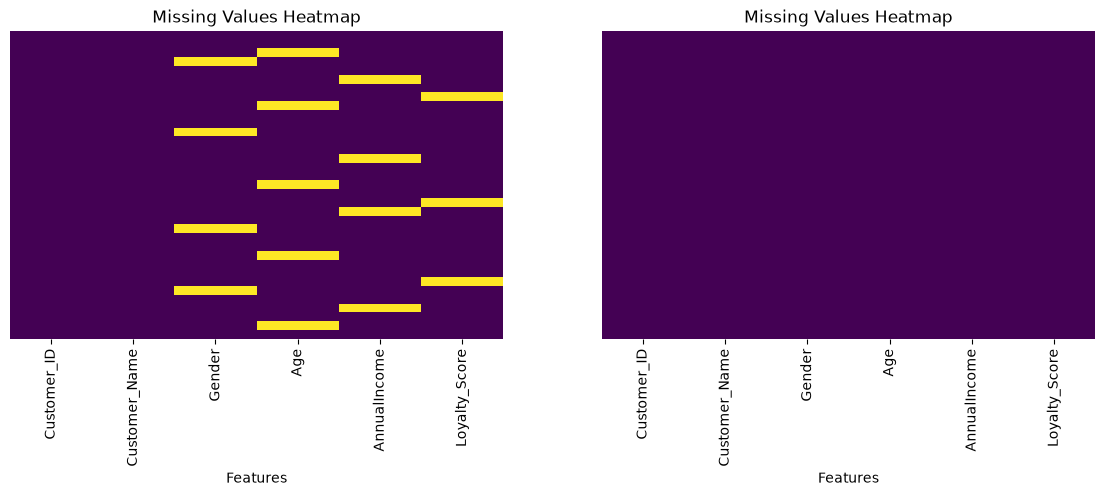

In [55]:
# Question 3(a) — Handling Missing Data via Imputation (Mode, Mean, Median)
# Write your code below
df_missing = pd.read_csv('missing_customers.csv')
print(df_missing.head(10))
missing_count = df_missing.isnull().sum()
missing_pct = (df_missing.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_pct
})
print(missing_report[missing_report['Missing Values'] > 0])
df_cleaned_imputed = df_missing.copy()
gender_mode = df_cleaned_imputed['Gender'].mode()[0]
df_cleaned_imputed['Gender'] = df_cleaned_imputed['Gender'].fillna(gender_mode)
print(gender_mode)
age_mean = df_cleaned_imputed['Age'].mean()
df_cleaned_imputed['Age'] = df_cleaned_imputed['Age'].fillna(round(age_mean, 1))
print(age_mean)
income_median = df_cleaned_imputed['AnnualIncome'].median()
df_cleaned_imputed['AnnualIncome'] = df_cleaned_imputed['AnnualIncome'].fillna(income_median)
print("AnnualIncome imputed with Median")
loyalty_mean = df_cleaned_imputed['Loyalty_Score'].mean()
df_cleaned_imputed['Loyalty_Score'] = df_cleaned_imputed['Loyalty_Score'].fillna(round(loyalty_mean, 1))
print(loyalty_mean)
print(df_cleaned_imputed.isnull().sum())
print(df_cleaned_imputed.isnull().sum().sum())

print(df_cleaned_imputed.head(10))
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.heatmap(df_missing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Features')

plt.subplot(1, 2, 2)
sns.heatmap(df_cleaned_imputed.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Features')

plt.show()

# Expected Output: Cleaned DataFrame with 0 missing values, all columns imputed according to specification

### Question 3(b) - Detecting and Dropping Rows with Incomplete Data in Internal Exam Results

A university wants to analyze exam results for internal assessment. But the dataset contains several rows with incomplete information, like missing Score, Subject, or Grade. (`exam_results.csv`)


In [56]:
# Question 3(b) — Detecting and Dropping Rows with Missing Data
# Write your code below
df_exam = pd.read_csv('exam_results.csv')
print(df_exam.head(10))
print("Original Dataset Shape")
rows_with_missing = df_exam[df_exam.isnull().any(axis=1)]
print(len(rows_with_missing))
print(rows_with_missing)
df_exam_cleaned = df_exam.dropna().reset_index(drop=True)
print(df_exam_cleaned.shape)
print(len(df_exam) - len(df_exam_cleaned))
print(df_exam_cleaned.head(10))

print(df_exam_cleaned['Internal_Score'].describe())

subject_summary = df_exam_cleaned.groupby('Subject')['Internal_Score'].agg(
    Student_Count='count',
    Average_Score='mean',
    Highest_Score='max',
    Lowest_Score='min'
).round(2)
print(subject_summary)

# Expected Output: Clean DataFrame with incomplete rows dropped, ready for statistical analysis

  Student_ID    Student_Name             Subject  Internal_Score Grade
0    MCA_101      Amit Chame        Data Science            55.0     B
1    MCA_102    Priya Sharma    Machine Learning            69.0     B
2    MCA_103     Rahul Patil  Python Programming            57.0     B
3    MCA_104  Sneha Deshmukh    Database Systems            64.0     B
4    MCA_105    Aniket Joshi     Cloud Computing             NaN     B
5    MCA_106  Pooja Kulkarni        Data Science            63.0     B
6    MCA_107    Rohan Shinde    Machine Learning            64.0     B
7    MCA_108      Tanvi More  Python Programming            70.0    B+
8    MCA_109    Aditya Kadam    Database Systems            62.0     B
9    MCA_110      Neha Pawar     Cloud Computing            59.0     B
Original Dataset Shape
5
   Student_ID     Student_Name           Subject  Internal_Score Grade
4     MCA_105     Aniket Joshi   Cloud Computing             NaN     B
10    MCA_111  Saurabh Gaikwad               NaN    

## Section 4: Exploratory Data Analysis (EDA): Univariate and Bivariate Analysis
**Course Outcome: CO2**

> Perform in-depth univariate and bivariate exploratory analysis using histograms, box plots, count plots, scatter plots, and regression plots.

### Question 4(a) - Customer Demographic and Spending Exploratory Data Analysis

A retail company has provided a customer dataset containing demographic and spending information such as age, gender, annual income, and spending score. Your task is to perform exploratory data analysis with the following goals: (`customer_data.csv`)


  Customer_ID            Name  Age  Gender  Annual_Income_k  Spending_Score
0       C_501      Amit Chame   22    Male               35              78
1       C_502    Priya Sharma   28  Female               48              85
2       C_503     Rahul Patil   35    Male               65              62
3       C_504  Sneha Deshmukh   42  Female               82              45
4       C_505    Aniket Joshi   26    Male               40              80


C:\Users\amitc\AppData\Local\Temp\ipykernel_14024\3181639692.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df_cust_eda, palette='Set2')


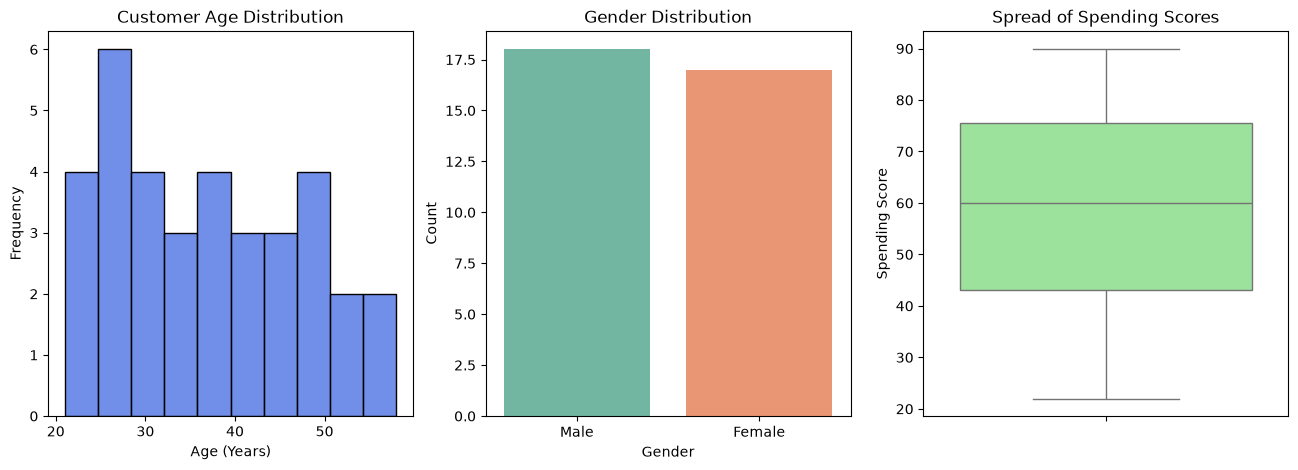

In [57]:
# Question 4(a) — Univariate Analysis on Customer Demographics & Spending
# Write your code below
df_cust_eda = pd.read_csv('customer_data.csv')
print(df_cust_eda.head())

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_cust_eda['Age'], bins=10, color='royalblue', edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
sns.countplot(x='Gender', data=df_cust_eda, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.subplot(1, 3, 3)
sns.boxplot(y=df_cust_eda['Spending_Score'], color='lightgreen')
plt.title('Spread of Spending Scores')
plt.ylabel('Spending Score')

plt.show()

# Expected Output: Three univariate plots visualizing Age distribution, Gender counts, and Spending Score spread

C:\Users\amitc\AppData\Local\Temp\ipykernel_14024\1647904134.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Spending_Score', data=df_cust_eda, palette='pastel')


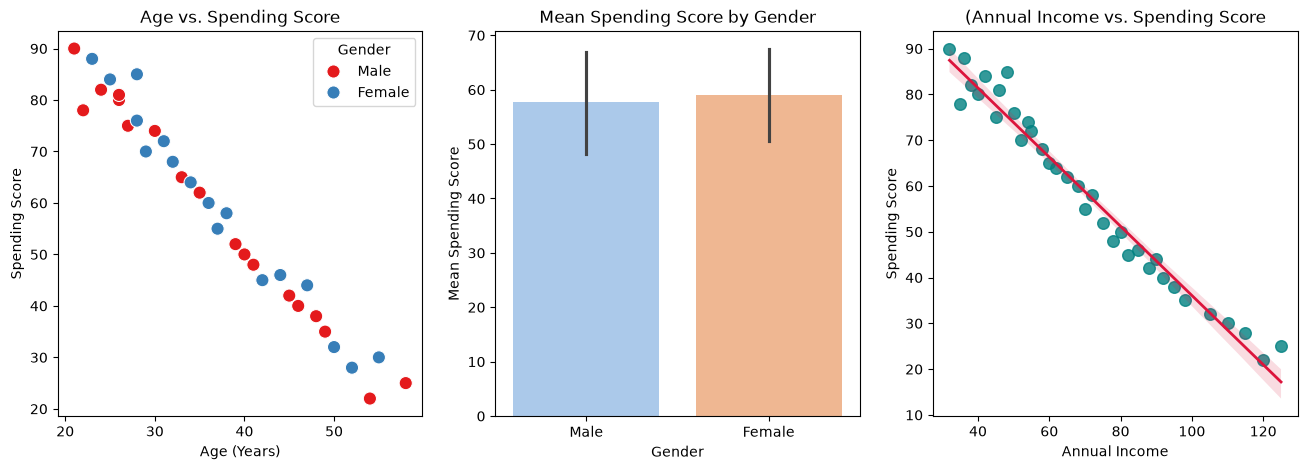

In [58]:
# Question 4(a) — Bivariate Analysis on Customer Demographics & Spending
# Write your code below

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='Spending_Score', data=df_cust_eda, hue='Gender', s=90, palette='Set1')
plt.title('Age vs. Spending Score')
plt.xlabel('Age (Years)')
plt.ylabel('Spending Score')
plt.subplot(1, 3, 2)
sns.barplot(x='Gender', y='Spending_Score', data=df_cust_eda, palette='pastel')
plt.title('Mean Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Spending Score')
plt.subplot(1, 3, 3)
sns.regplot(x='Annual_Income_k', y='Spending_Score', data=df_cust_eda,
            scatter_kws={'color': 'teal', 's': 70}, line_kws={'color': 'crimson', 'linewidth': 2})
plt.title('(Annual Income vs. Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

# Expected Output: Three bivariate plots illustrating Age vs Spending, Gender vs Spending, and Income vs Spending regression

### Question 4(b) - Retail Sales Exploratory Data Analysis

You are provided with a retail sales dataset containing product categories, unit prices, quantities sold, total sales, and regional information. Your task is to perform exploratory data analysis with the following objectives: (`product_sales.csv`)



   Order_ID Product_Name     Category  Unit_Price  Quantity  Total_Sales  \
0  ORD_8001   Smartphone  Electronics       18000         4        72000   
1  ORD_8002       Laptop  Electronics       52000         5       260000   
2  ORD_8003     Smart TV  Electronics       28000         3        84000   
3  ORD_8004   Headphones  Accessories        2500         5        12500   
4  ORD_8005   Smartwatch  Accessories        3500         5        17500   

  Region  
0  North  
1  South  
2   East  
3   West  
4  North  


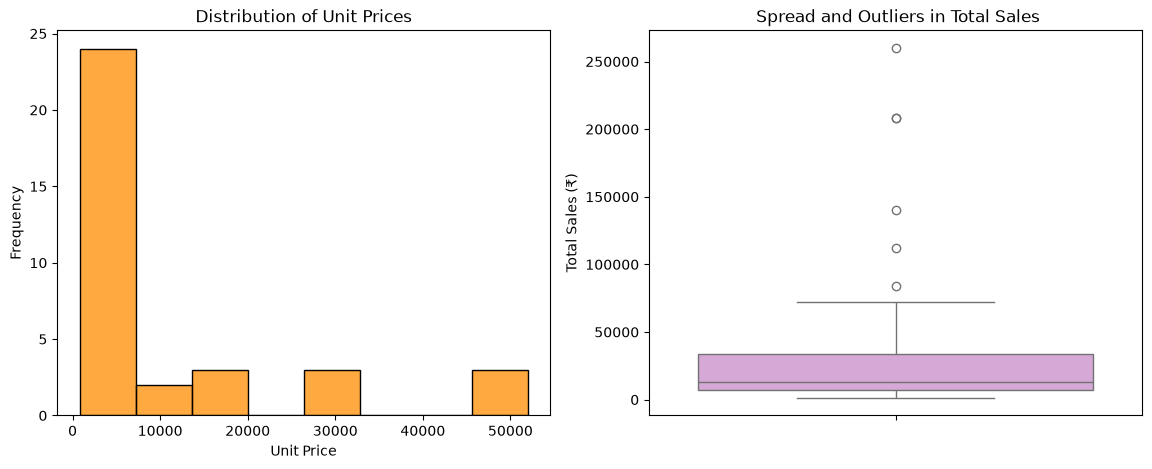

In [ ]:
# Question 4(b) — Univariate Analysis on Retail Sales Dataset
# Write your code below

df_prod_sales = pd.read_csv('product_sales.csv')
print(df_prod_sales.head())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_prod_sales['Unit_Price'], bins=8, color='darkorange')
plt.title('Distribution of Unit Prices')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_prod_sales['Total_Sales'], color='plum')
plt.title(' Spread and Outliers in Total Sales')
plt.ylabel('Total Sales (₹)')
plt.show()

# Expected Output: Univariate plots showing Unit Price distribution and Total Sales spread

C:\Users\amitc\AppData\Local\Temp\ipykernel_14024\3491990200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Sales', y='Category', data=cat_sales_summary, palette='viridis')
C:\Users\amitc\AppData\Local\Temp\ipykernel_14024\3491990200.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Total_Sales', data=df_prod_sales, estimator=sum, errorbar=None, palette='coolwarm')


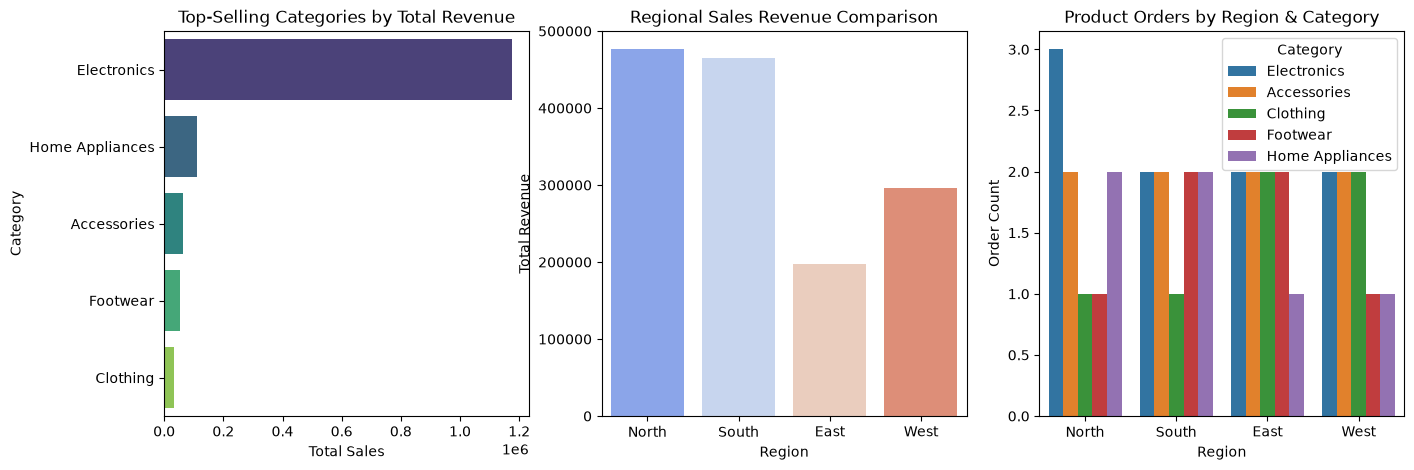

In [ ]:
# Question 4(b) — Bivariate Analysis on Retail Sales Dataset
# Write your code below

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
cat_sales_summary = df_prod_sales.groupby('Category')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False)
sns.barplot(x='Total_Sales', y='Category', data=cat_sales_summary, palette='viridis')
plt.title('Top-Selling Categories by Total Revenue')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.subplot(1, 3, 2)
sns.barplot(x='Region', y='Total_Sales', data=df_prod_sales)
plt.title('Regional Sales Revenue Comparison')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.subplot(1, 3, 3)
sns.countplot(x='Region', hue='Category', data=df_prod_sales, palette='tab10')
plt.title('Product Orders by Region & Category')
plt.xlabel('Region')
plt.ylabel('Order Count')

plt.show()

# Expected Output: Bivariate plots showing category ranking, regional sales comparison, and cross-region category counts

## Section 5: Exploratory Data Analysis (EDA): Multivariate Analysis
**Course Outcome: CO2**

> Perform multivariate exploratory analysis to investigate multi-variable interactions, group comparisons, correlation structures, and pair-wise distributions.

### Question 5(a) - Student Academic Performance Multivariate Analysis

An educational institution wants to understand how students' performance in Math, Reading, and Writing is influenced by gender, parental education level, and lunch type. Your task is to conduct multivariate analysis to uncover key relationships and visualize how multiple variables interact to influence academic scores. (`student_scores.csv`)



  Student_ID    Student_Name  Gender  Parental_Education    Lunch_Type  \
0    STU_301      Amit Chame    Male         High School      Standard   
1    STU_302    Priya Sharma  Female  Associate's Degree  Free/Reduced   
2    STU_303     Rahul Patil    Male   Bachelor's Degree      Standard   
3    STU_304  Sneha Deshmukh  Female     Master's Degree  Free/Reduced   
4    STU_305    Aniket Joshi    Male         High School      Standard   

   Math_Score  Reading_Score  Writing_Score  
0          62             70             75  
1          61             61             65  
2          81             85             90  
3          83             80             82  
4          79             75             75  
        Math_Score  Reading_Score  Writing_Score
Gender                                          
Female       71.29          71.71          73.24
Male         76.72          79.72          80.28


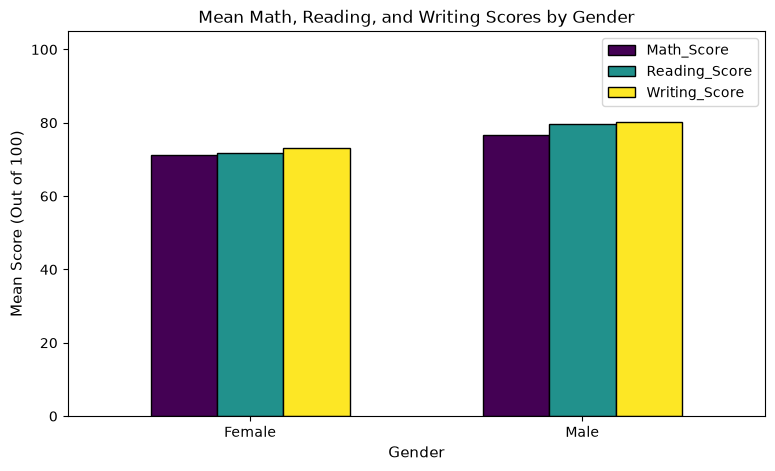

In [61]:
# Question 5(a)(i) — Average Performance Across Gender (Grouped Bar Chart)
# Write your code below
df_students = pd.read_csv('student_scores.csv')
print(df_students.head())
gender_scores = df_students.groupby('Gender')[['Math_Score', 'Reading_Score', 'Writing_Score']].mean()
print(gender_scores.round(2))

ax = gender_scores.plot(kind='bar', figsize=(9, 5), colormap='viridis', edgecolor='black', width=0.6)
plt.title('Mean Math, Reading, and Writing Scores by Gender')
plt.xlabel('Gender', fontsize=11)
plt.ylabel('Mean Score (Out of 100)', fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, 105)

plt.show()

# Expected Output: Grouped bar chart comparing average Math, Reading, and Writing scores between Male and Female

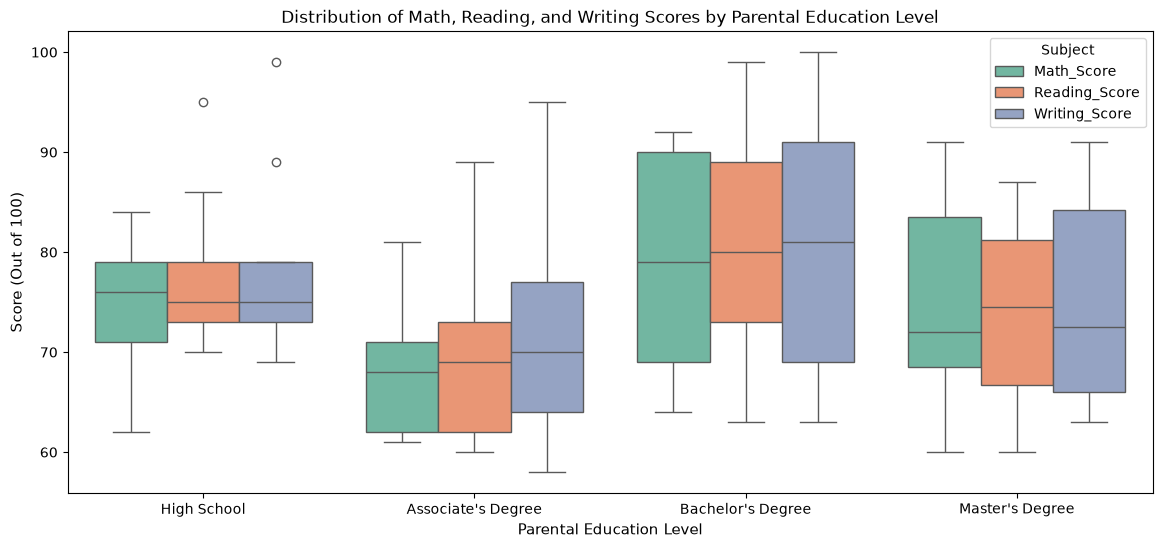

In [62]:
# Question 5(a)(ii) — Effect of Parental Education on Student Scores (Grouped Box Plots)
# Write your code below
df_melted_edu = pd.melt(
    df_students,
    id_vars=['Student_ID', 'Student_Name', 'Gender', 'Parental_Education', 'Lunch_Type'],
    value_vars=['Math_Score', 'Reading_Score', 'Writing_Score'],
    var_name='Subject',
    value_name='Score'
)

plt.figure(figsize=(14, 6))
education_order = ['High School', "Associate's Degree", "Bachelor's Degree", "Master's Degree"]

sns.boxplot(
    x='Parental_Education',
    y='Score',
    hue='Subject',
    data=df_melted_edu,
    order=education_order,
    palette='Set2'
)

plt.title('Distribution of Math, Reading, and Writing Scores by Parental Education Level')
plt.xlabel('Parental Education Level', fontsize=11)
plt.ylabel('Score (Out of 100)', fontsize=11)
plt.show()

# Expected Output: Box plot showing score distributions across parental education levels for all 3 subjects

             Math_Score       Reading_Score        Writing_Score       
                   mean   std          mean    std          mean    std
Lunch_Type                                                             
Free/Reduced      71.29  9.08         71.71   9.33         73.24  11.09
Standard          76.72  9.01         79.72  10.32         80.28  11.21


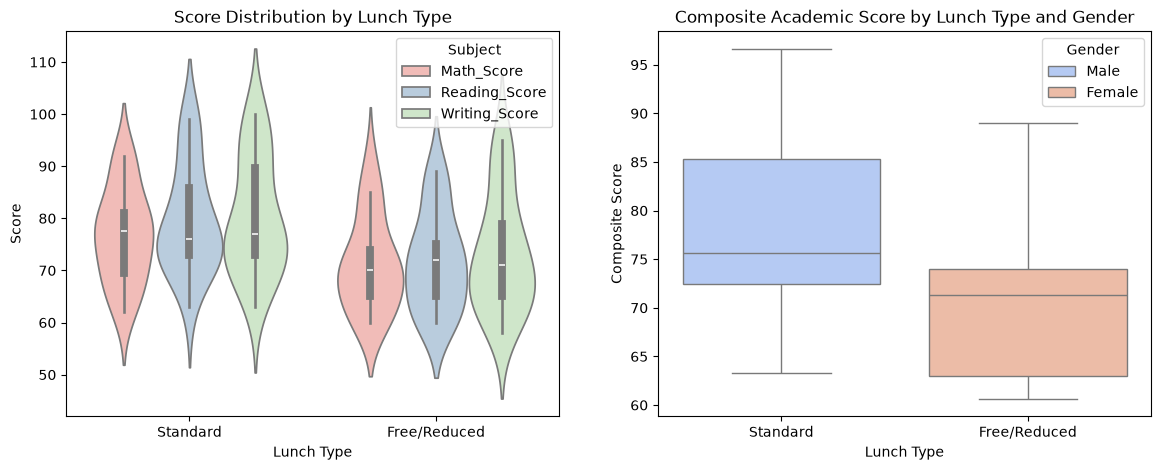

In [63]:
# Question 5(a)(iii) — Impact of Lunch Type on Academic Performance (Violin Plot & Summary)
# Write your code below

lunch_summary = df_students.groupby('Lunch_Type')[['Math_Score', 'Reading_Score', 'Writing_Score']].agg(['mean', 'std']).round(2)
print(lunch_summary)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.violinplot(
    x='Lunch_Type',
    y='Score',
    hue='Subject',
    data=df_melted_edu,
    palette='Pastel1',
    split=False
)
plt.title('Score Distribution by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Score')
plt.legend(title='Subject')
plt.subplot(1, 2, 2)
df_students['Composite_Score'] = (df_students['Math_Score'] + df_students['Reading_Score'] + df_students['Writing_Score']) / 3
sns.boxplot(
    x='Lunch_Type',
    y='Composite_Score',
    hue='Gender',
    data=df_students,
    palette='coolwarm'
)
plt.title('Composite Academic Score by Lunch Type and Gender')
plt.xlabel('Lunch Type')
plt.ylabel('Composite Score')
plt.legend(title='Gender')
plt.show()

# Expected Output: Violin plot and box plot demonstrating performance differences between Standard and Free/Reduced lunch

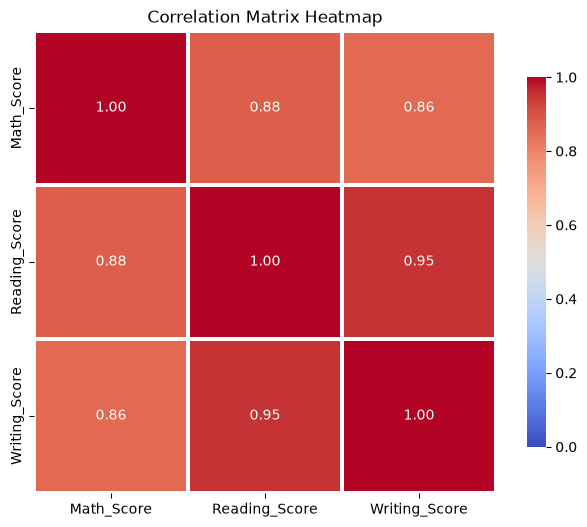

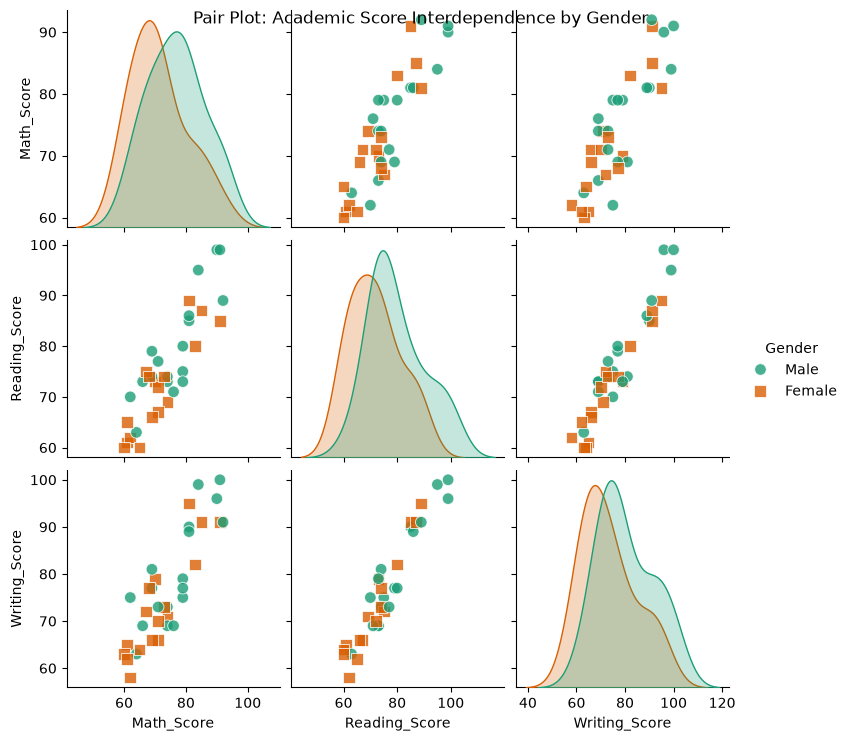

In [64]:
# Question 5(a)(iv) — Correlation Heatmap and Pair Plot for Score Interdependence
# Write your code below

# Compute Correlation Matrix
score_corr = df_students[['Math_Score', 'Reading_Score', 'Writing_Score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(score_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1, square=True, linewidths=1.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.show()
pair_grid = sns.pairplot(
    df_students,
    vars=['Math_Score', 'Reading_Score', 'Writing_Score'],
    hue='Gender',
    palette='Dark2',
    diag_kind='kde',
    markers=["o", "s"],
    plot_kws={'alpha': 0.8, 's': 70}
)
pair_grid.fig.suptitle('Pair Plot: Academic Score Interdependence by Gender')
plt.show()

# Expected Output: Correlation heatmap and pair plot showing positive linear correlations among all three subjects

---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | Amit Chame |
| **PRN** | 125M1H020 |
| **Date** | 26-08-2026 |

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-03-green?style=flat-square)

</div>